# Interactive EGFR Cascade Simulation

## Light Pattern Builder

In [40]:
import numpy as np
import json
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

class LightPatternBuilder:
    def __init__(self, t_max=100):
        self.style = {"description_width": "70px"}
        self.slider_layout = widgets.Layout(width="280px")
        self.t_max_slider = widgets.FloatSlider(
            value=t_max, min=10, max=500, step=5,
            description="t_max", style=self.style, layout=self.slider_layout,
        )
        self.pulses = []
        self.pulse_container = widgets.VBox()
        self.plot_out = widgets.Output()

        add_btn = widgets.Button(description="+ Add pulse", button_style="success",
                                  layout=widgets.Layout(width="120px"))
        add_btn.on_click(lambda _: self._add_pulse())

        save_btn = widgets.Button(description="Save pattern", button_style="primary",
                                   layout=widgets.Layout(width="120px"))
        save_btn.on_click(self._save)
        self.save_out = widgets.Output()

        top = widgets.HBox([self.t_max_slider, add_btn, save_btn, self.save_out])
        self.ui = widgets.VBox([top, self.pulse_container, self.plot_out])

        self.t_max_slider.observe(lambda _: self._refresh_plot(), names="value")
        self._add_pulse(t_on=0, t_off=5, amplitude=1.0)

    def _add_pulse(self, t_on=None, t_off=None, amplitude=1.0):
        idx = len(self.pulses)
        t_on = t_on if t_on is not None else idx * 15
        t_off = t_off if t_off is not None else t_on + 5

        on_s = widgets.FloatSlider(value=t_on, min=0, max=500, step=0.5,
                                    description="t_on", style=self.style, layout=self.slider_layout)
        off_s = widgets.FloatSlider(value=t_off, min=0, max=500, step=0.5,
                                     description="t_off", style=self.style, layout=self.slider_layout)
        amp_s = widgets.FloatSlider(value=amplitude, min=0, max=5, step=0.05,
                                     description="amplitude", style=self.style, layout=self.slider_layout)
        rm_btn = widgets.Button(description="x", button_style="danger",
                                 layout=widgets.Layout(width="35px"))

        pulse = {"on": on_s, "off": off_s, "amp": amp_s, "btn": rm_btn}
        self.pulses.append(pulse)

        for s in (on_s, off_s, amp_s):
            s.observe(lambda _: self._refresh_plot(), names="value")

        rm_btn.on_click(lambda _, p=pulse: self._remove_pulse(p))
        row = widgets.HBox([widgets.Label(f"#{idx+1}", layout=widgets.Layout(width="30px")),
                            on_s, off_s, amp_s, rm_btn])
        pulse["row"] = row
        self._rebuild_container()
        self._refresh_plot()

    def _remove_pulse(self, pulse):
        if pulse in self.pulses:
            self.pulses.remove(pulse)
            self._rebuild_container()
            self._refresh_plot()

    def _rebuild_container(self):
        for i, p in enumerate(self.pulses):
            p["row"].children[0].value = f"#{i+1}"
        self.pulse_container.children = [p["row"] for p in self.pulses]

    def get_pulses(self):
        return [{"t_on": p["on"].value, "t_off": p["off"].value, "amplitude": p["amp"].value}
                for p in self.pulses]

    def light_func(self, t_val, t_args=None):
        """Evaluate the light pattern at time t_val. Compatible with Model API."""
        pulses = t_args.get("pulses") if t_args and "pulses" in t_args else self.get_pulses()
        return sum(p["amplitude"] for p in pulses if p["t_on"] <= t_val <= p["t_off"])

    def _refresh_plot(self):
        pulses = self.get_pulses()
        t_max = self.t_max_slider.value
        times = np.linspace(0, t_max, 1000)
        vals = [self.light_func(tv, {"pulses": pulses}) for tv in times]

        with self.plot_out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 1.8))
            ax.fill_between(times, vals, alpha=0.35, color="gold")
            ax.plot(times, vals, color="orange", linewidth=1)
            ax.set_ylabel("Light")
            ax.set_xlabel("Time")
            ax.set_xlim(0, t_max)
            ax.set_ylim(bottom=-0.05)
            plt.tight_layout()
            plt.show()

    def _save(self, _):
        pattern = {"t_max": self.t_max_slider.value, "pulses": self.get_pulses()}
        path = "light_pattern.json"
        with open(path, "w") as f:
            json.dump(pattern, f, indent=2)
        with self.save_out:
            clear_output(wait=True)
            print(f"Saved to {path}")

    def display(self):
        display(self.ui)

light_builder = LightPatternBuilder()
light_builder.display()

In [41]:
import pandas as pd
df = pd.read_parquet('./dataset.parquet')
df['ramp_pattern_name'].unique()

array(['3-2-1minIntervals', 'Single', 'Sustained', 'ramp1'], dtype=object)

In [42]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

from model.mechanistic.mechanistic_model import Model
from model.mechanistic.egfr_simplified import model_eqs, PARAM_NAMES, STATE_NAMES, NODE_NAMES

In [43]:
def light_pulse(t_val, t_args=None):
    """Light on from t_on to t_off, off otherwise."""
    t_on = t_args.get("t_on", 0) if t_args else 0
    t_off = t_args.get("t_off", 5) if t_args else 5
    return 1.0 if t_on <= t_val <= t_off else 0.0

m = Model(
    name="egfr_interactive",
    states=STATE_NAMES,
    parameters=PARAM_NAMES,
    model_definition=model_eqs,
    t_dep="light",
    t_func=light_pulse,
)
system = m.make_numerical()

to_hand_pick = 'egfr_params.json'

In [44]:
DEFAULTS = {
    "Km": 0.1,
    # RAS: fast activation by light, strong GAP-mediated deactivation
    "k12": 0.8,  "k21": 1.5,
    # RAF: moderate activation by RAS, NFB-sensitive deactivation
    "k34": 0.5,  "knfb": 0.8, "k43": 0.3,
    # MEK: dual-phosphorylation by RAF, PP2A deactivation
    "k56": 0.6,  "k65": 1.2,
    # ERK: dual-phosphorylation by MEK, phosphatase deactivation
    "k78": 0.5,  "k87": 1.0,
    # NFB (DUSP/Sprouty-like): slow transcriptional feedback from ERK
    "f12": 0.08, "f21": 0.05,
}
if to_hand_pick is not None: 
    with open(to_hand_pick, 'r') as f:
        DEFAULTS = json.load(f)
print(f"Using {to_hand_pick or 'Default'} parameters: {DEFAULTS}")

COLORS = {"RAS": "#e41a1c", "RAF": "#377eb8", "MEK": "#4daf4a", "NFB": "#984ea3", "ERK": "#ff7f00"}

def simulate_and_plot(**kwargs):
    t_end = kwargs.pop("t_end")
    t_on = kwargs.pop("t_on")
    t_off = kwargs.pop("t_off")

    params_vec = np.array([kwargs[p] for p in PARAM_NAMES])
    times = np.linspace(0, t_end, 500)
    y0 = np.zeros(len(STATE_NAMES))
    t_args = {"t_on": t_on, "t_off": t_off}

    sol = solve_ivp(
        lambda t, y: system(t, y, params_vec, light_pulse, t_args),
        [0, t_end], y0, t_eval=times, method="LSODA", rtol=1e-8,
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), height_ratios=[1, 4],
                                    sharex=True, gridspec_kw={"hspace": 0.05})

    # Light stimulus
    light_vals = [light_pulse(tv, t_args) for tv in times]
    ax1.fill_between(times, light_vals, alpha=0.3, color="gold")
    ax1.set_ylabel("Light")
    ax1.set_ylim(-0.05, 1.15)
    ax1.set_yticks([0, 1])

    # State trajectories
    if sol.success:
        for i, node in enumerate(NODE_NAMES):
            y_plot = sol.y[i]
            if node == "NFB":
                nfb_max = np.max(y_plot)
                if nfb_max > 1e-12:
                    y_plot = y_plot / nfb_max
                label = "NFB (norm)"
            else:
                label = node
            ax2.plot(times, y_plot, label=label, color=COLORS[node], linewidth=2)
        ax2.legend(loc="upper right")
    else:
        ax2.text(0.5, 0.5, f"Solver failed: {sol.message}", transform=ax2.transAxes,
                 ha="center", color="red", fontsize=12)

    ax2.set_xlabel("Time")
    ax2.set_ylabel("Active fraction")
    ax2.set_ylim(bottom=-0.02)
    plt.tight_layout()
    plt.show()

Using egfr_params.json parameters: {'Km': 0.251188643150958, 'k12': 0.35481338923357547, 'k21': 0.11220184543019636, 'k34': 0.7079457843841379, 'knfb': 2.2387211385683394, 'k43': 0.03162277660168379, 'k56': 2.2387211385683394, 'k65': 0.31622776601683794, 'k78': 1.5848931924611136, 'k87': 0.14125375446227545, 'f12': 3.1622776601683795, 'f21': 0.7943282347242815}


In [45]:
style = {"description_width": "60px"}

param_sliders = {
    p: widgets.FloatLogSlider(
        value=DEFAULTS[p], base=10, min=-2, max=2, step=0.05,
        description=p, style=style, layout=widgets.Layout(width="350px"),
    )
    for p in PARAM_NAMES
}

sim_sliders = {
    "t_end": widgets.FloatSlider(value=30, min=5, max=100, step=1, description="t_end", style=style,
                                  layout=widgets.Layout(width="350px")),
    "t_on": widgets.FloatSlider(value=0, min=0, max=50, step=0.5, description="t_on", style=style,
                                 layout=widgets.Layout(width="350px")),
    "t_off": widgets.FloatSlider(value=5, min=0, max=50, step=0.5, description="t_off", style=style,
                                  layout=widgets.Layout(width="350px")),
}

# Group sliders by cascade layer
km_box = widgets.VBox([widgets.Label("Shared"), param_sliders["Km"]])
ras_box = widgets.VBox([widgets.Label("RAS"), param_sliders["k12"], param_sliders["k21"]])
raf_box = widgets.VBox([widgets.Label("RAF"), param_sliders["k34"], param_sliders["knfb"], param_sliders["k43"]])
mek_box = widgets.VBox([widgets.Label("MEK"), param_sliders["k56"], param_sliders["k65"]])
erk_box = widgets.VBox([widgets.Label("ERK"), param_sliders["k78"], param_sliders["k87"]])
nfb_box = widgets.VBox([widgets.Label("NFB"), param_sliders["f12"], param_sliders["f21"]])
sim_box = widgets.VBox([widgets.Label("Simulation"), *sim_sliders.values()])

left = widgets.VBox([km_box, ras_box, raf_box, mek_box])
right = widgets.VBox([erk_box, nfb_box, sim_box])
controls = widgets.HBox([left, right])

out = widgets.interactive_output(simulate_and_plot, {**param_sliders, **sim_sliders})
display(controls, out)

Output()

In [46]:
import json

def save_params(b):
    current = {p: param_sliders[p].value for p in PARAM_NAMES}
    path = "egfr_params.json"
    with open(path, "w") as f:
        json.dump(current, f, indent=2)
    print(f"Saved to {path}: {current}")

save_btn = widgets.Button(description="Save params")
save_btn.on_click(save_params)
display(save_btn)

Button(description='Save params', style=ButtonStyle())

## Simulate across all light patterns

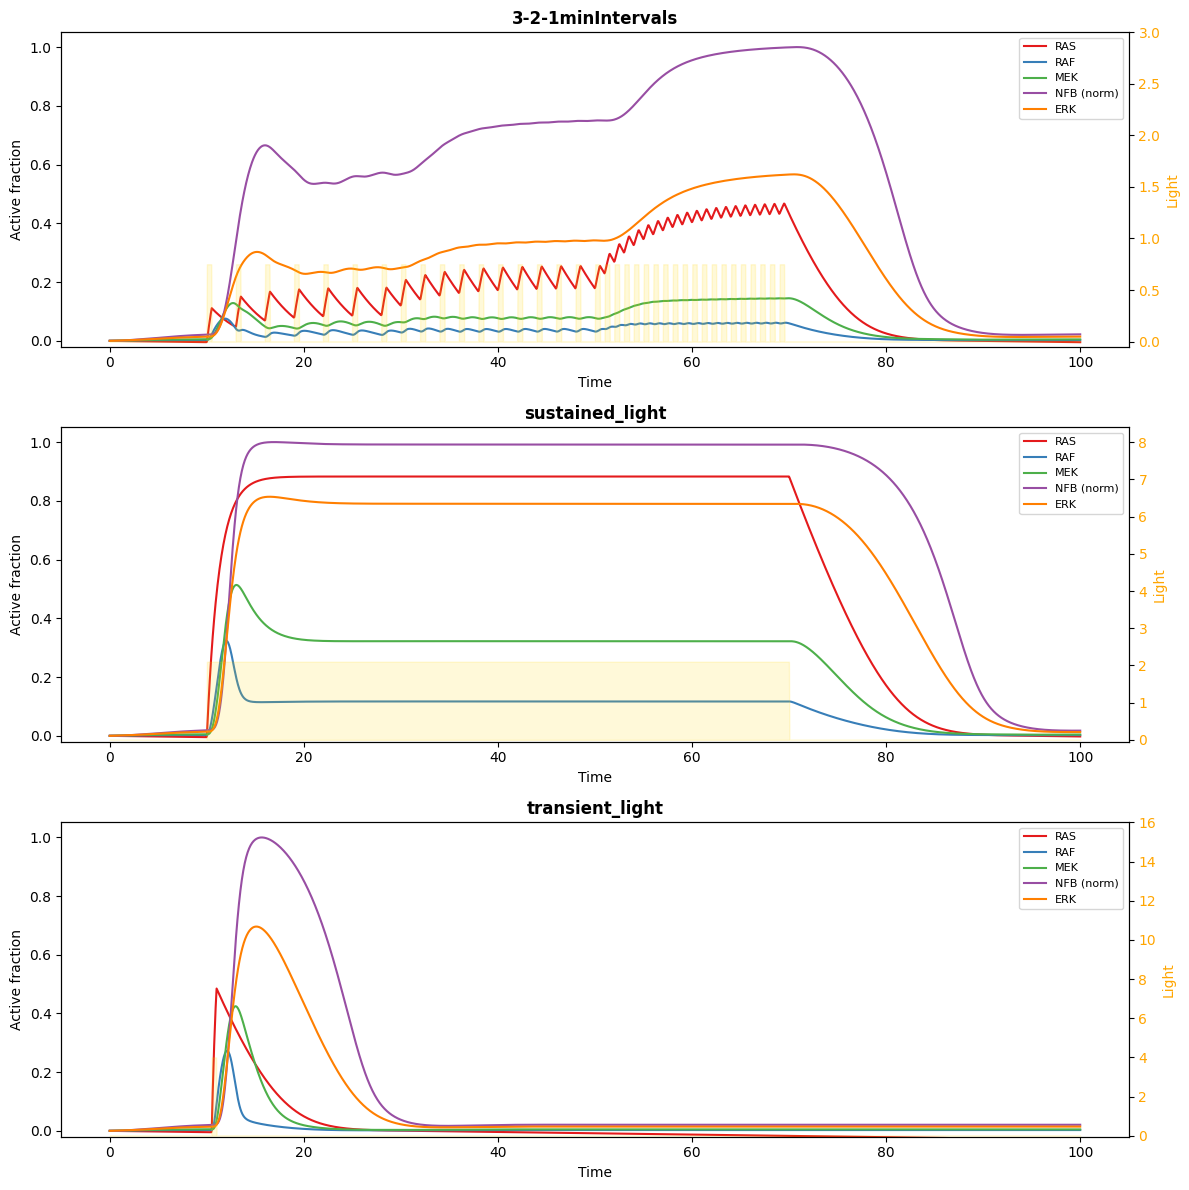

Patterns: ['3-2-1minIntervals', 'sustained_light', 'transient_light']
Params: {'Km': 0.2512, 'k12': 0.3548, 'k21': 0.1122, 'k34': 0.7079, 'knfb': 2.2387, 'k43': 0.0316, 'k56': 2.2387, 'k65': 0.3162, 'k78': 1.5849, 'k87': 0.1413, 'f12': 3.1623, 'f21': 0.7943}


In [47]:
from glob import glob

def load_pattern(path):
    with open(path) as f:
        return json.load(f)

def pattern_light_func(t_val, t_args=None):
    pulses = t_args["pulses"]
    return sum(p["amplitude"] for p in pulses if p["t_on"] <= t_val <= p["t_off"])

pattern_files = sorted(glob("*_pattern.json"))
patterns = {p.replace("_pattern.json", ""): load_pattern(p) for p in pattern_files}

# Use current slider params
params_vec = np.array([param_sliders[p].value for p in PARAM_NAMES])

fig, axes = plt.subplots(len(patterns), 1, figsize=(12, 4 * len(patterns)), squeeze=False)

for ax_row, (name, pattern) in zip(axes, patterns.items()):
    ax = ax_row[0]
    t_max = pattern["t_max"]
    times = np.linspace(0, t_max, 2000)
    t_args = {"pulses": pattern["pulses"]}

    # Simulate
    y0 = np.zeros(len(STATE_NAMES))
    sol = solve_ivp(
        lambda t, y: system(t, y, params_vec, pattern_light_func, t_args),
        [0, t_max], y0, t_eval=times, method="LSODA", rtol=1e-8,
    )

    # Light on twin axis
    ax_light = ax.twinx()
    light_vals = [pattern_light_func(tv, t_args) for tv in times]
    ax_light.fill_between(times, light_vals, alpha=0.15, color="gold")
    ax_light.set_ylabel("Light", color="orange")
    ax_light.set_ylim(-0.05, max(light_vals) * 4 if max(light_vals) > 0 else 1)
    ax_light.tick_params(axis="y", labelcolor="orange")

    # State trajectories
    if sol.success:
        for i, node in enumerate(NODE_NAMES):
            y_plot = sol.y[i]
            if node == "NFB":
                nfb_max = np.max(y_plot)
                if nfb_max > 1e-12:
                    y_plot = y_plot / nfb_max
                label = "NFB (norm)"
            else:
                label = node
            ax.plot(times, y_plot, label=label, color=COLORS[node], linewidth=1.5)
    else:
        ax.text(0.5, 0.5, f"Solver failed: {sol.message}", transform=ax.transAxes,
                ha="center", color="red")

    ax.set_title(name, fontweight="bold")
    ax.set_ylabel("Active fraction")
    ax.set_xlabel("Time")
    ax.set_ylim(bottom=-0.02)
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()
print(f"Patterns: {list(patterns.keys())}")
print(f"Params: { {p: round(param_sliders[p].value, 4) for p in PARAM_NAMES} }")

/var/folders/92/3gzjc7p14mvb4pqkx2ryk0680000gn/T/ipykernel_6637/2720519392.py:274: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


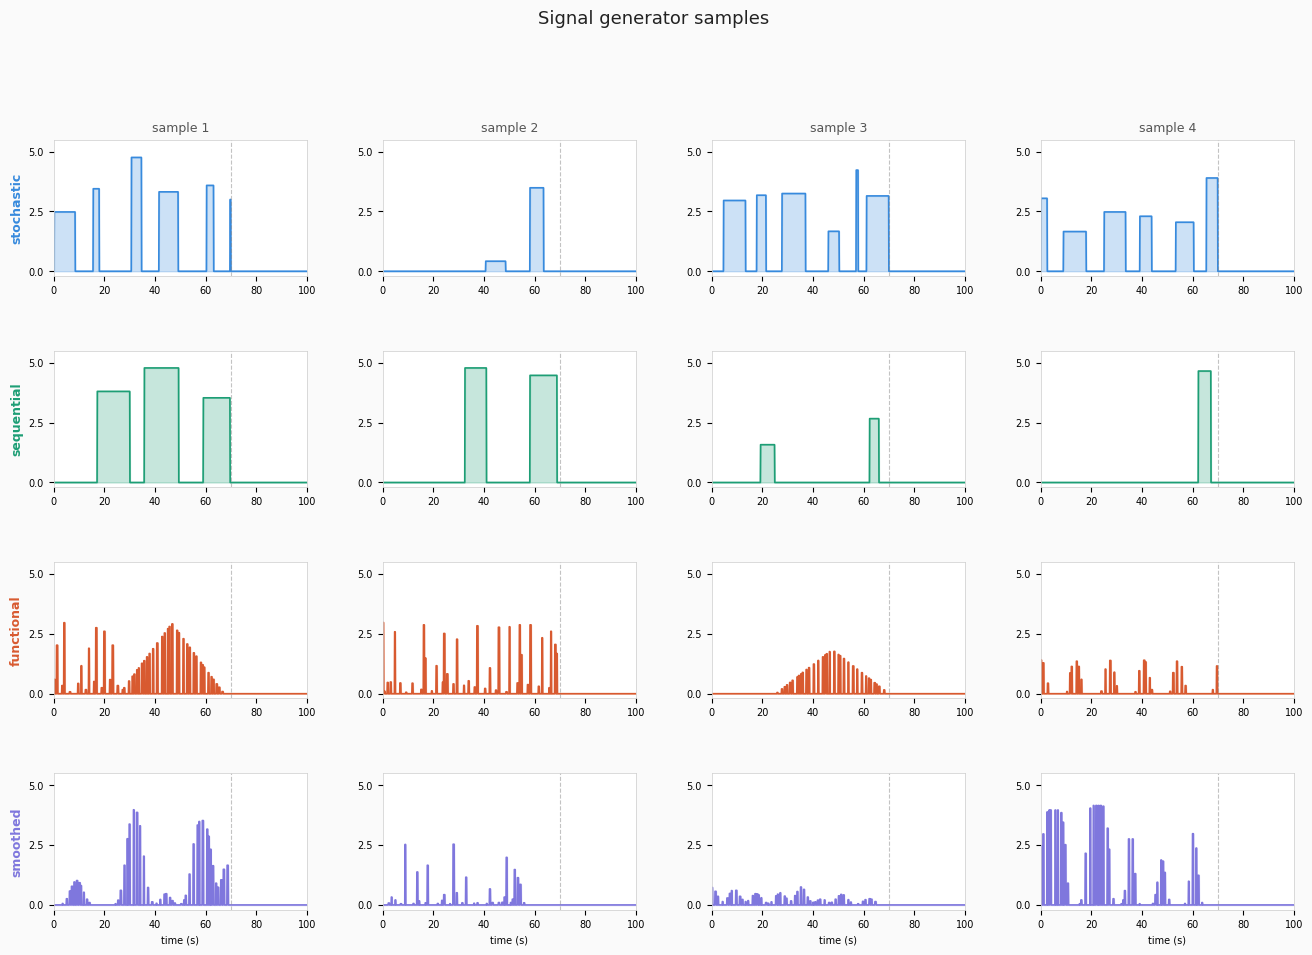

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d


# --- helpers ---

def _pulses_to_signal(pulses: list, times: np.ndarray, dt: float) -> np.ndarray:
    signal = np.zeros(len(times))
    for p in pulses:
        on_idx  = int(p["t_on"]  / dt)
        off_idx = int(p["t_off"] / dt)
        signal[on_idx:off_idx] = p["amplitude"]
    return signal

def _signal_to_pulses_fragmented(
    signal: np.ndarray,
    times: np.ndarray,
    dt: float,
    rng: np.random.Generator,
    min_duration: float = 0.5,
    amp_range: tuple = (0.1, 5.0),
) -> list:
    """
    Fragment a continuous signal into short pulses that sample the envelope.
    Each pulse duration is exactly min_duration; gap between pulses is randomly sampled.
    Amplitude of each pulse is read from the signal at that timepoint.
    Pulses with amplitude below threshold are skipped.
    """
    amp_threshold = amp_range[0] * 0.5
    pulse_samples = max(1, int(min_duration / dt))

    pulses = []
    i = 0
    while i < len(signal):
        amp = float(signal[i])
        if amp > amp_threshold:
            t_on  = round(float(times[i]), 2)
            t_off = round(float(times[min(i + pulse_samples - 1, len(times) - 1)]), 2)
            pulses.append({
                "t_on":      t_on,
                "t_off":     t_off,
                "amplitude": round(amp, 2),
            })
            gap_samples = int(rng.uniform(0.1, 1.5) / dt)
            i += pulse_samples + gap_samples
        else:
            i += 1

    return pulses


def _sample_amplitude(rng, amp_lo, amp_hi, a=3.0, b=0.35):
    """
    Beta(a, b) mapped onto [amp_lo, amp_hi].
    Default a=b=2 gives a symmetric hill (mid-amplitudes more likely).
    Tweak a, b per generator for different biases:
      a=0.5, b=0.5  -> U-shaped (prefer extremes)
      a=2,   b=5    -> skewed low
      a=5,   b=2    -> skewed high
    """
    return amp_lo + (amp_hi - amp_lo) * rng.beta(a, b)


# --- generators ---

def generate_stochastic_pulses(
    t_max: float = 100.0,
    t_cutoff: float = 70.0,
    dt: float = 0.1,
    amplitude_range: tuple = (0.1, 5.0),
    rng: np.random.Generator = None,
) -> dict:
    """At each timepoint, randomly decide if a pulse starts (Poisson-like)."""
    if rng is None:
        rng = np.random.default_rng()

    threshold   = rng.uniform(0.05, 0.4)
    min_gap     = rng.uniform(0.5, 5.0)
    amp_lo, amp_hi = amplitude_range
    # skew toward mid-to-high amplitudes
    beta_a, beta_b = rng.uniform(1.5, 4.0), rng.uniform(1.5, 4.0)

    times = np.arange(0, t_max, dt)
    cutoff_idx = int(t_cutoff / dt)

    pulses = []
    i = 0
    while i < cutoff_idx:
        if rng.uniform() < threshold * dt:
            t_on     = times[i]
            duration = rng.uniform(0.5, 10.0)
            t_off    = min(t_on + duration, t_cutoff)
            amplitude = round(float(_sample_amplitude(rng, amp_lo, amp_hi, beta_a, beta_b)), 2)
            pulses.append({"t_on": round(t_on, 2), "t_off": round(t_off, 2), "amplitude": amplitude})
            gap = rng.uniform(min_gap, min_gap + 3.0)
            i += int((duration + gap) / dt)
        else:
            i += 1

    return {"t_max": t_max, "pulses": pulses}


def generate_sequential_pulses(
    t_max: float = 100.0,
    t_cutoff: float = 70.0,
    t_start_min: float = 1.0,
    amplitude_range: tuple = (0.1, 5.0),
    rng: np.random.Generator = None,
    **kwargs,
) -> dict:
    """Sequential pulse placement with random duration / amplitude / gap."""
    if rng is None:
        rng = np.random.default_rng()

    min_duration = rng.uniform(0.5, 3.0)
    max_duration = rng.uniform(min_duration, 15.0)
    min_gap      = rng.uniform(0.5, 5.0)
    max_pulses   = rng.integers(1, 6)
    amp_lo, amp_hi = amplitude_range
    # U-shaped: more likely to be clearly on or clearly off
    beta_a, beta_b = 1.6, 0.6

    pulses = []
    t_cursor = t_start_min

    for _ in range(max_pulses):
        remaining = t_cutoff - t_cursor
        if remaining < min_duration:
            break
        duration  = rng.uniform(min_duration, min(max_duration, remaining))
        #amplitude = round(float(_sample_amplitude(rng, amp_lo, amp_hi, beta_a, beta_b)), 2)
        t_on      = rng.uniform(t_cursor, t_cutoff - duration)
        t_off     = t_on + duration
        amplitude = round(float(_sample_amplitude(rng, amp_lo, amp_hi, beta_a, beta_b)), 2)
        pulses.append({"t_on": round(t_on, 2), "t_off": round(t_off, 2), "amplitude": amplitude})
        t_cursor  = t_off + rng.uniform(min_gap, min_gap + 3.0)

    return {"t_max": t_max, "pulses": pulses}


def generate_functional_pulses(
    t_max: float = 100.0,
    t_cutoff: float = 70.0,
    dt: float = 0.1,
    amplitude_range: tuple = (0.1, 3.5),
    rng: np.random.Generator = None,
) -> dict:
    """Stitch random functional segments (sin, cos, linear, square) over [0, t_cutoff]."""
    if rng is None:
        rng = np.random.default_rng()

    times = np.arange(0, t_max, dt)
    cutoff_idx = int(t_cutoff / dt)
    signal = np.zeros(len(times))
    amp_lo, amp_hi = amplitude_range
    # skew high — functional signals tend to look flat at low amplitude
    beta_a, beta_b = 3.0, 1.5

    def _sin(t, freq, amp):    return amp * np.sin(2 * np.pi * freq * t)
    def _cos(t, freq, amp):    return amp * np.cos(2 * np.pi * freq * t)
    def _square(t, freq, amp): return amp * np.sign(np.sin(2 * np.pi * freq * t))
    def _linear(t, _, amp):    # ramp up/down; ignores freq
        mid = t[-1] / 2 if t[-1] > 0 else 1
        return amp * (1 - np.abs(t - mid) / mid)

    func_pool = [_sin, _cos, _linear, _square]

    t_cursor = 0.0
    freq = rng.uniform(0.01, 0.5)
    while t_cursor < t_cutoff:
        seg_duration  = rng.uniform(10.0, 60.0)
        t_end         = min(t_cursor + seg_duration, t_cutoff)
        seg_start_idx = int(t_cursor / dt)
        seg_end_idx   = int(t_end   / dt)
        t_seg         = times[seg_start_idx:seg_end_idx] - t_cursor

        freq =+ rng.normal(0, 0.2)
        amp  = _sample_amplitude(rng, amp_lo, amp_hi, beta_a, beta_b)
        
        fn   = rng.choice(func_pool)

        seg_signal = fn(t_seg, freq, amp)
        seg_signal = np.clip(seg_signal, 0, amp_hi)
        signal[seg_start_idx:seg_end_idx] = seg_signal
        t_cursor = t_end

    pulses = _signal_to_pulses_fragmented(signal[:cutoff_idx], times[:cutoff_idx], dt, rng, amp_range=amplitude_range)
    return {"t_max": t_max, "pulses": pulses}


def generate_smoothed_pulses(
    t_max: float = 100.0,
    t_cutoff: float = 70.0,
    dt: float = 0.1,
    amplitude_range: tuple = (0.1, 5.0),
    rng: np.random.Generator = None,
    base_generator=None,
) -> dict:
    if rng is None:
        rng = np.random.default_rng()
    if base_generator is None:
        base_generator = rng.choice([
            generate_stochastic_pulses,
            generate_sequential_pulses,
            generate_functional_pulses,
        ])

    base   = base_generator(t_max=t_max, t_cutoff=t_cutoff, dt=dt,
                            amplitude_range=amplitude_range, rng=rng)
    times  = np.arange(0, t_max, dt)
    signal = _pulses_to_signal(base["pulses"], times, dt)

    sigma    = rng.uniform(1.0, 20.0)
    smoothed = gaussian_filter1d(signal, sigma=sigma)
    smoothed = np.clip(smoothed, 0, amplitude_range[1])

    cutoff_idx = int(t_cutoff / dt)

    # fragment the smoothed envelope into short discrete pulses
    pulses = _signal_to_pulses_fragmented(
        smoothed[:cutoff_idx], times[:cutoff_idx], dt, rng,
        min_duration=0.5, amp_range=amplitude_range,
    )
    return {"t_max": t_max, "pulses": pulses}


# --- plot ---

def plot_signal_grid(t_max: float = 100.0, dt: float = 0.1, seed: int = 44):
    rng   = np.random.default_rng(seed)
    times = np.arange(0, t_max, dt)

    generators = [
        ("stochastic", generate_stochastic_pulses),
        ("sequential", generate_sequential_pulses),
        ("functional", generate_functional_pulses),
        ("smoothed",   generate_smoothed_pulses),
    ]
    colors = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD"]

    fig = plt.figure(figsize=(16, 10))
    fig.patch.set_facecolor("#FAFAFA")
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.3)

    for row, (label, gen_fn) in enumerate(generators):
        for col in range(4):
            ax     = fig.add_subplot(gs[row, col])
            result = gen_fn(t_max=t_max, rng=rng)
            signal = _pulses_to_signal(result["pulses"], times, dt)

            ax.fill_between(times, signal, alpha=0.25, color=colors[row])
            ax.plot(times, signal, lw=1.2, color=colors[row])
            ax.axvline(70, color="#888", lw=0.8, ls="--", alpha=0.5)

            ax.set_xlim(0, t_max)
            ax.set_ylim(-0.2, 5.5)
            ax.set_yticks([0, 2.5, 5])
            ax.tick_params(labelsize=7)
            ax.set_facecolor("white")
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)
                spine.set_color("#CCCCCC")

            if col == 0:
                ax.set_ylabel(label, fontsize=9, fontweight="bold", color=colors[row])
            if row == 0:
                ax.set_title(f"sample {col + 1}", fontsize=9, color="#555")
            if row == 3:
                ax.set_xlabel("time (s)", fontsize=7)

    fig.suptitle("Signal generator samples", fontsize=13, y=1.01, color="#222")
    plt.tight_layout()
    plt.savefig("signal_grid.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_signal_grid(seed=7)